# GraphVAMP teaching path: contact graphs, VAMP-2, and implied timescales

This notebook is a **diagnostic / teaching** walkthrough of the molecular
toolchain boundary in KoopmanGraph: build a unit-aware contact graph, fit the
graph-aware variational approach for Markov processes (VAMP-2) baseline, and
compare implied timescales to a deeptime reference when available. It shows
how the synthetic two-state oracle, GraphVAMP fit/score, and feature-space
timescale diagnostics compose — and where they intentionally diverge.

**Objective.** Reproduce the teaching contract in interactive form: contact
graph → GraphVAMP fit → independent feature-space implied timescales → optional
deeptime rank-order comparison on the same features.

**Fixture.** Seeded synthetic two-state oracle (`generate_synthetic_two_state`)
so the notebook runs without `[md]` or alanine data. Positions and cutoffs are
in **nanometres** (nm); the teaching timestep is **1 ps** per snapshot. Every
implied timescale below reports its **unit** and the **lag** used in
$t = -\tau / \ln\lvert\lambda\rvert$.

> **Honesty.** This is **not** a PyEMMA replacement, **not** a protocol-matched
> GraphVAMPNet reproduction (Ghorbani et al., 2022), and **not**
> Folding@home-scale molecular dynamics. GraphVAMP embeddings are **not** the
> features used for the timescale / deeptime block below.


## Setup


In [1]:
from __future__ import annotations

import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import numpy as np
import torch

import koopman_graph
from koopman_graph.analysis import implied_timescales
from koopman_graph.baselines import GraphVAMPBaseline
from koopman_graph.datasets.molecular import (
    contact_edge_index,
    generate_synthetic_two_state,
)

print(f"koopman_graph {koopman_graph.__version__}")
print("Notebook written against koopman_graph 0.11.x teaching APIs.")

SEED = 1
NUM_TIMESTEPS = 512
LAG_STEPS = 1
EPOCHS = 15
TOP_K = 2
torch.manual_seed(SEED)
np.random.seed(SEED)


koopman_graph 0.11.0
Notebook written against koopman_graph 0.11.x teaching APIs.


## Motivation and background

Markov state model (MSM) and VAMP toolchains typically start from featurized
molecular trajectories, estimate a lag-$\tau$ operator, and report implied
timescales $t = -\tau / \ln\lvert\lambda\rvert$ as a kinetic diagnostic (Wu &
Noé, 2020). Graph neural variants such as GraphVAMPNet (Ghorbani et al., 2022)
and VAMPnets (Mardt et al., 2018) learn features that maximize a VAMP score,
but production MSM stacks (PyEMMA, deeptime workflows) remain a separate
software surface.

KoopmanGraph's molecular path exposes a **thin teaching boundary**: unit-aware
contact graphs, a pooled-GCN `GraphVAMPBaseline` that maximizes the in-repo
topology-blind VAMP-2 score, and analysis-owned `implied_timescales`. The
naive alternative is to paste coordinates into an external MSM script without
unit guards or a reproducible oracle. This notebook keeps that boundary
explicit and uses a closed-form two-state contact-graph fixture so CI and
readers share the same ground truth.


## Minimal example — synthetic contact graph

The generator places four atoms on a line (nm), builds oriented contacts with
a documented cutoff, and switches node-feature patterns with a symmetric
Markov flip probability $p = 0.05$. The closed-form slow eigenvalue is
$\lambda = 1 - 2p = 0.9$; the oracle implied timescale at lag
$\tau = 1$ snapshot is $t = -1 / \ln 0.9$ **steps**.


In [2]:
traj = generate_synthetic_two_state(num_timesteps=NUM_TIMESTEPS, seed=SEED)
edges_from_positions = contact_edge_index(traj.positions_nm, cutoff_nm=0.5)

assert torch.equal(edges_from_positions, traj.edge_index)
print(f"dataset_id={traj.dataset_id} version={traj.version}")
print(f"nodes={traj.positions_nm.shape[0]} timesteps={traj.sequence.num_timesteps}")
print(f"positions unit=nm; cutoff=0.5 nm; timestep={traj.timestep_ps} ps / snapshot")
print(f"contact edge_index shape={tuple(traj.edge_index.shape)}")
print(
    f"oracle slow timescale={traj.oracle_slow_timescale_steps:.4f} steps "
    f"(lag={traj.oracle_lag_steps} steps; λ={traj.slow_eigenvalue})"
)


dataset_id=synthetic_two_state_v1 version=v1
nodes=4 timesteps=512
positions unit=nm; cutoff=0.5 nm; timestep=1.0 ps / snapshot
contact edge_index shape=(2, 3)
oracle slow timescale=9.4912 steps (lag=1 steps; λ=0.9)


## Progressive deep dive — GraphVAMP fit, then feature-space timescales

### GraphVAMP teaching baseline

`GraphVAMPBaseline` encodes each snapshot with a thin graph convolutional
network (GCN), mean-pools to a graph embedding, and maximizes the existing
topology-blind VAMP-2 score on lag pairs. It is inspired by GraphVAMPNet
(Ghorbani et al., 2022) but is not a protocol-matched reproduction. deeptime
is **not** required for fit/score.


In [3]:
model = GraphVAMPBaseline(
    in_channels=2,
    hidden_channels=8,
    latent_dim=4,
    num_layers=1,
)
model.fit(
    traj.sequence,
    lag=LAG_STEPS,
    epochs=EPOCHS,
    lr=1e-2,
    edge_index=traj.edge_index,
)
vamp2 = float(model.score(traj.sequence, lag=LAG_STEPS))
print(f"GraphVAMP VAMP-2 score={vamp2:.4f} (lag={LAG_STEPS} steps)")


GraphVAMP VAMP-2 score=0.8583 (lag=1 steps)


### Independent diagnostic: implied timescales on flattened node features

The rank-order oracle below uses **flattened node features** (same dictionary
as the CI test), **not** GraphVAMP embeddings. We form an empirical lag-
`LAG_STEPS` Koopman matrix by least squares on mean-centered pairs and convert
eigenvalues with `implied_timescales`. Invalid modes
($\lvert\lambda\rvert \approx 0$ or $\lvert\lambda\rvert \ge 1$) appear as
$+\infty$ with `valid=False` — never silent `NaN`. Units here are **snapshot
steps** because we pass `lag_steps` only.


In [4]:
features = np.stack(
    [
        traj.sequence[t].x.detach().cpu().numpy().reshape(-1)
        for t in range(traj.sequence.num_timesteps)
    ],
    axis=0,
).astype(np.float64)

x = torch.as_tensor(features[:-LAG_STEPS], dtype=torch.float64)
y = torch.as_tensor(features[LAG_STEPS:], dtype=torch.float64)
x = x - x.mean(dim=0)
y = y - y.mean(dim=0)
koopman = torch.linalg.lstsq(x, y).solution
eigenvalues = torch.linalg.eigvals(koopman)
report = implied_timescales(eigenvalues, lag_steps=LAG_STEPS)

inrepo = report.timescales[report.valid].detach().cpu().numpy()
inrepo = np.sort(inrepo[np.isfinite(inrepo) & (inrepo > 0.0)])[::-1]

print(f"lag τ = {report.tau} {report.unit} (lag_steps={report.lag_steps})")
for i, t_i in enumerate(inrepo[:TOP_K]):
    print(
        f"in-repo timescale[{i}] = {t_i:.4f} {report.unit} "
        f"(lag={LAG_STEPS} steps)"
    )
print(
    f"oracle slow timescale = {traj.oracle_slow_timescale_steps:.4f} steps "
    f"(lag={traj.oracle_lag_steps} steps)"
)


lag τ = 1.0 steps (lag_steps=1)
in-repo timescale[0] = 12.8981 steps (lag=1 steps)
in-repo timescale[1] = 0.4070 steps (lag=1 steps)
oracle slow timescale = 9.4912 steps (lag=1 steps)


### Optional deeptime comparison (same features)

When `deeptime` is installed (`pip install 'koopman-graph[msm]'`), we fit VAMP
on the **same flattened features** and compare the **rank order** of the
leading two implied timescales plus a loose relative bound on the slowest mode.
Exact numeric agreement is not the contract: VAMP's covariance/SVD pipeline and
the in-repo least-squares Koopman matrix are different estimators. If deeptime
is absent, this cell records a skip and the notebook still completes.


In [5]:
deeptime_top = None
deeptime_slow_rel = None

try:
    from deeptime.decomposition import VAMP

    from koopman_graph.interop import trajectory_features_to_deeptime

    dataset = trajectory_features_to_deeptime(features, lag=LAG_STEPS)
    assert dataset.trajectory.shape == features.shape

    vamp_model = VAMP(lagtime=LAG_STEPS).fit(features).fetch_model()
    deeptime_ts = np.asarray(vamp_model.timescales(), dtype=float)
    deeptime_ts = np.sort(deeptime_ts[np.isfinite(deeptime_ts) & (deeptime_ts > 0.0)])[
        ::-1
    ]

    assert inrepo.shape[0] >= TOP_K and deeptime_ts.shape[0] >= TOP_K
    inrepo_top = inrepo[:TOP_K]
    deeptime_top = deeptime_ts[:TOP_K]

    for i, t_i in enumerate(deeptime_top):
        print(
            f"deeptime timescale[{i}] = {t_i:.4f} steps "
            f"(lag={LAG_STEPS} steps)"
        )

    assert inrepo_top[0] > 5.0 * inrepo_top[1]
    assert deeptime_top[0] > 5.0 * deeptime_top[1]
    assert np.argsort(-inrepo_top).tolist() == np.argsort(-deeptime_top).tolist()

    deeptime_slow_rel = abs(inrepo_top[0] - deeptime_top[0]) / max(
        inrepo_top[0], deeptime_top[0]
    )
    print(f"slow-mode relative difference = {deeptime_slow_rel:.3f} (tol < 0.5)")
    assert deeptime_slow_rel < 0.5
    print("deeptime rank-order check: passed")
except ImportError:
    print(
        "deeptime not installed; skipped rank-order comparison. "
        "Install with: pip install 'koopman-graph[msm]'"
    )


deeptime timescale[0] = 13.1134 steps (lag=1 steps)
deeptime timescale[1] = 0.5703 steps (lag=1 steps)
slow-mode relative difference = 0.016 (tol < 0.5)
deeptime rank-order check: passed


## Results — VAMP-2 score, timescales, and the oracle gap

Look at three quantities side by side: (1) the GraphVAMP VAMP-2 score on pooled
GCN embeddings, (2) the leading feature-space implied timescale from the
in-repo least-squares estimator, and (3) the closed-form oracle
$t = -\tau / \ln(0.9)$. The bar chart compares slow-mode timescales only.
Expect a **visible gap** between the feature-space estimate and the oracle on
this short noisy trajectory — the contract is rank-order / diagnostic hygiene,
not oracle matching. If deeptime ran above, its slow mode should sit near the
in-repo estimate (relative difference less than $0.5$), not necessarily on
the oracle.


GraphVAMP VAMP-2 score          = 0.8583 (lag=1 steps)
in-repo slow timescale          = 12.8981 steps (lag=1 steps)
oracle slow timescale           = 9.4912 steps (lag=1 steps)
|in-repo - oracle| / oracle     = 0.359
deeptime slow timescale         = 13.1134 steps (lag=1 steps)
slow-mode |in-repo - deeptime| / max = 0.016


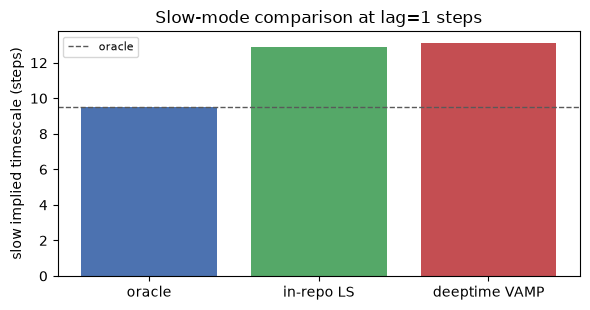

In [6]:
oracle = float(traj.oracle_slow_timescale_steps)
inrepo_slow = float(inrepo[0]) if inrepo.size else float("nan")
rel_oracle = abs(inrepo_slow - oracle) / oracle

print(f"GraphVAMP VAMP-2 score          = {vamp2:.4f} (lag={LAG_STEPS} steps)")
print(
    f"in-repo slow timescale          = {inrepo_slow:.4f} steps "
    f"(lag={LAG_STEPS} steps)"
)
print(
    f"oracle slow timescale           = {oracle:.4f} steps "
    f"(lag={traj.oracle_lag_steps} steps)"
)
print(f"|in-repo - oracle| / oracle     = {rel_oracle:.3f}")
if deeptime_top is not None:
    print(
        f"deeptime slow timescale         = {float(deeptime_top[0]):.4f} steps "
        f"(lag={LAG_STEPS} steps)"
    )
    print(f"slow-mode |in-repo - deeptime| / max = {deeptime_slow_rel:.3f}")
else:
    print("deeptime slow timescale         = skipped (deeptime not installed)")

labels = ["oracle", "in-repo LS"]
values = [oracle, inrepo_slow]
if deeptime_top is not None:
    labels.append("deeptime VAMP")
    values.append(float(deeptime_top[0]))

fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.bar(labels, values, color=["#4C72B0", "#55A868", "#C44E52"][: len(labels)])
ax.set_ylabel(f"slow implied timescale ({report.unit})")
ax.set_title(f"Slow-mode comparison at lag={LAG_STEPS} steps")
ax.axhline(oracle, color="0.35", linestyle="--", linewidth=1.0, label="oracle")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()


## Interpretation

The GraphVAMP score answers whether the pooled-GCN embeddings are VAMP-2-
trainable on this contact graph; it does **not** certify recovery of the
two-state timescale. The feature-space least-squares spectrum is a separate
diagnostic aligned with the CI oracle tests. On 512 noisy frames the leading
in-repo timescale typically overshoots the closed-form oracle (see the
relative error printed in Results) while still separating a slow mode from a
fast residual — useful for rank-order checks against deeptime, not for claiming
kinetic accuracy.

Prefer this path when you need unit-explicit contacts and a reproducible
teaching oracle inside KoopmanGraph. Prefer a full MSM / deeptime / PyEMMA
workflow when you need production featurization, lag selection, and Chapman–
Kolmogorov validation on real MD. The method breaks down if coordinates are
supplied in ångströms without conversion (nm is required), if GraphVAMP
latents are mistaken for the timescale feature dictionary, or if a single lag's
implied timescales are treated as continuous-time rates.


## Takeaways

- Reach for `contact_edge_index` + `GraphVAMPBaseline` when you want a
  unit-explicit teaching contact graph and a pooled-GCN VAMP-2 score inside
  KoopmanGraph — not when you need a GraphVAMPNet or PyEMMA production stack.
- Report every implied timescale with $\tau$ and its unit; modes with
  $\lvert\lambda\rvert \ge 1$ or near zero are invalid (`valid=False`,
  timescale $+\infty$).
- Treat GraphVAMP fit/score and feature-space `implied_timescales` as
  **separate** steps; this notebook's timescale / deeptime block uses
  flattened node features, not GraphVAMP embeddings.
- Do not expect feature-space timescales to match the closed-form oracle on
  this short noisy fixture — use the gap as a diagnostic (rank order vs
  deeptime), not as a kinetic accuracy claim.
- Cutoff validation rejects unreasonably large `cutoff_nm` values (greater
  than $5\,\mathrm{nm}$) with an ångström-conversion hint; convert positions
  yourself ($1\,\mathrm{\AA} = 0.1\,\mathrm{nm}$) before calling.
- The synthetic oracle supplies a known slow process for CI and demos. A
  fetch-based alanine path remains optional and is not required here.


## Further reading

- Ghorbani, M., Prasad, S., Klauda, J. B., & Brooks, B. R. (2022). GraphVAMPNet,
  using graph neural networks and variational approach to Markov processes for
  dynamical modeling of biomolecules. *The Journal of Chemical Physics*,
  *156*(18), 184103. https://doi.org/10.1063/5.0085607
- Wu, H., & Noé, F. (2020). Variational approach for learning Markov processes
  from time series data. *Journal of Nonlinear Science*, *30*(1), 23–66.
  https://doi.org/10.1007/s00332-019-09567-y
- Mardt, A., Pasquali, L., Wu, H., & Noé, F. (2018). VAMPnets for deep learning
  of molecular kinetics. *Nature Communications*, *9*, 5.
  https://doi.org/10.1038/s41467-017-02388-1
- API:
  [`GraphVAMPBaseline`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`implied_timescales`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  molecular loaders in
  [`koopman_graph.datasets.molecular`](https://koopmangraph.readthedocs.io/en/latest/api.html)
  (see also the Sphinx [data](https://koopmangraph.readthedocs.io/en/latest/data.html)
  notes for `synthetic_two_state_v1`).
- Tutorials index:
  [tutorials](https://koopmangraph.readthedocs.io/en/latest/tutorials.html)
  (this notebook is the GraphVAMP / MD teaching entry).
- Related package docs: [capabilities](https://koopmangraph.readthedocs.io/en/latest/capabilities.html),
  [limitations](https://koopmangraph.readthedocs.io/en/latest/limitations.html).
